In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("GSE54553_series_matrix.csv.xlsx")
            

In [3]:
df.head()

,!series_matrix_table_begin,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,ID_REF,GSM1318741,GSM1318742,GSM1318743,GSM1318744,GSM1318745,GSM1318746,GSM1318747,GSM1318748,GSM1318749,GSM1318750
1,AFFX-BioB-3_at,5.872,6.003,5.793,6.011,6.077,5.738,6.058,5.895,5.87,5.75
2,AFFX-BioB-5_at,6.26,6.692,6.42,6.454,6.447,6.347,6.632,6.216,6.307,6.222
3,AFFX-BioB-M_at,5.682,6.149,5.929,6.198,6.035,5.819,6.197,5.997,5.868,5.879
4,AFFX-BioC-3_at,8.04,8.197,8.095,8.218,8.143,8.024,8.344,8.116,8.006,7.904


In [4]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,ID_REF,GSM1318741,GSM1318742,GSM1318743,GSM1318744,GSM1318745,GSM1318746,GSM1318747,GSM1318748,GSM1318749,GSM1318750
1,AFFX-BioB-3_at,5.872,6.003,5.793,6.011,6.077,5.738,6.058,5.895,5.87,5.75
2,AFFX-BioB-5_at,6.26,6.692,6.42,6.454,6.447,6.347,6.632,6.216,6.307,6.222
3,AFFX-BioB-M_at,5.682,6.149,5.929,6.198,6.035,5.819,6.197,5.997,5.868,5.879
4,AFFX-BioC-3_at,8.04,8.197,8.095,8.218,8.143,8.024,8.344,8.116,8.006,7.904
5,AFFX-BioC-5_at,6.942,7.242,7.149,7.177,7.134,6.972,7.336,7.077,7.022,6.902


In [5]:
df.columns

Index(['ID_REF', 'GSM1318741', 'GSM1318742', 'GSM1318743', 'GSM1318744',
       'GSM1318745', 'GSM1318746', 'GSM1318747', 'GSM1318748', 'GSM1318749',
       'GSM1318750'],
      dtype='object', name=0)

In [6]:
print(df.shape)

(61290, 11)


In [8]:
infected = ['GSM1318741', 'GSM1318742', 'GSM1318743', 
            'GSM1318744', 'GSM1318745']
control = ['GSM1318746', 'GSM1318747', 'GSM1318748',
            'GSM1318749', 'GSM1318750']
infected_mean = df[infected].mean(axis=1)
control_mean = df[control].mean(axis=1)
df['logFC'] = infected_mean-control_mean
df[['ID_REF','logFC']].head()


,ID_REF,logFC
1,AFFX-BioB-3_at,0.089
2,AFFX-BioB-5_at,0.1098
3,AFFX-BioB-M_at,0.0466
4,AFFX-BioC-3_at,0.0598
5,AFFX-BioC-5_at,0.067


In [9]:
upregulated = df[df['logFC']>1]
downregulated = df[df['logFC']<-1]
print("Upregulated genes:", upregulated.shape)
print("Downregulated genes:", downregulated.shape)

Upregulated genes: (1068, 12)
Downregulated genes: (193, 12)


In [10]:
top_up = upregulated.sort_values(by='logFC', ascending=False)
top_down = downregulated.sort_values(by='logFC')
print("Top Upregulated Genes")
print(top_up[['ID_REF','logFC']].head(10))
print("\nTop Downregulated Genes")
print(top_down[['ID_REF','logFC']].head(10))



Top Upregulated Genes
0                      ID_REF   logFC
15186        Ta.25789.1.A1_at  8.4978
20032        Ta.30810.1.S1_at  7.1678
28875         Ta.8329.1.A1_at  6.7754
58969  TaAffx.86581.1.S1_s_at  6.7704
20209        Ta.30951.1.S1_at   6.711
20073        Ta.30842.1.S1_at  6.5068
15192        Ta.25797.1.A1_at  6.5024
29094         Ta.8492.1.S1_at  6.4208
20066        Ta.30836.1.S1_at   6.306
20094        Ta.30865.1.S1_at  6.2902

Top Downregulated Genes
0                   ID_REF   logFC
17172   Ta.27778.2.S1_x_at -2.8006
6284    Ta.15268.1.S1_x_at -2.7932
17173   Ta.27778.4.S1_x_at -2.7744
17799   Ta.28312.1.S1_x_at -2.6852
12869  Ta.23142.11.S1_x_at -2.6732
19974     Ta.30782.4.S1_at -2.6468
12872   Ta.23142.6.S1_x_at -2.6416
3582    Ta.12643.5.S1_x_at -2.6004
13627     Ta.24114.8.S1_at -2.5828
17798     Ta.28312.1.S1_at  -2.582


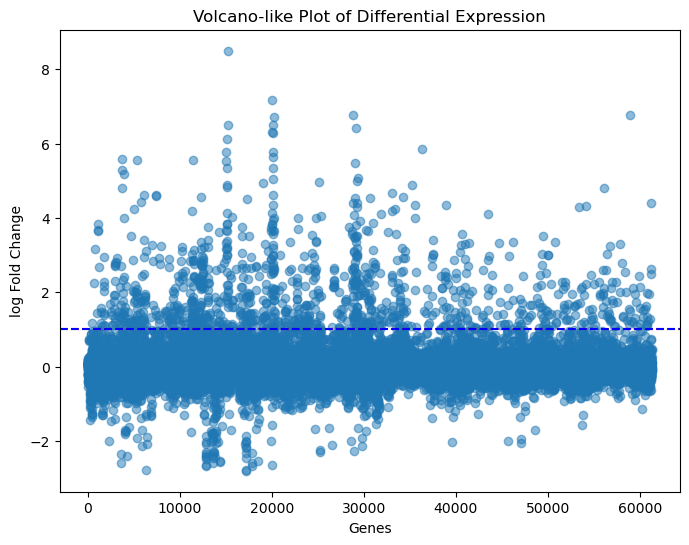

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df.index, df['logFC'], alpha=0.5)
plt.axhline(y=1, color='red', linestyle='--')
plt.axhline(y=1, color='blue', linestyle='--')
plt.xlabel("Genes")
plt.ylabel("log Fold Change")
plt.title("Volcano-like Plot of Differential Expression")
plt.show()


In [13]:
top_up[['ID_REF', 'logFC']].head(50).to_csv("top_upregulated_genes.csv", index=False)
top_down[['ID_REF', 'logFC']].head(50).to_csv("top_downregulated_genes.csv", index=False)
print("Files saved successfully")

Files saved successfully
